In [1]:
# Standard imports
import json
from collections import OrderedDict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================================
# DATASET SWITCH - change this single string to run on Link instead of Array
# ============================================================================
DATASET_NAME = "Array"   # options: "Array", "Link"

# Project paths follow the sandbox_v1 convention
PROJECT_ROOT = (
    Path.home()
    / "mece_project_inverse_model"
    / "Generative_Inverse_Design_of_High-Speed_Interconnects"
)
DATA_PT = (
    PROJECT_ROOT / "data" / "processed" / f"Universal-Diff-SI-{DATASET_NAME}"
    / "diff_pair_dataset.pt"
)

# Output directory is dataset-specific so Array and Link can coexist
EDA_OUT_DIR = (
    PROJECT_ROOT / "results" / "data" / "frequency_eda" / DATASET_NAME.lower()
)
EDA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Forward model checkpoint - update this per dataset if needed
FORWARD_MODEL_PATH = (
    PROJECT_ROOT / "sandbox_v1" / "models" / "forward_runs"
    / "run_2026-06-01_213554_direct_resnet_array" / "checkpoint_best.pt"
)

# Constants used throughout the analysis
NOISE_FLOOR_DB = -45.0        # per Hillebrecht et al. IEEE TEMC 2024
EPS = 1e-12                    # log10 floor to prevent -inf at zeros

# Linear-scale signal-power thresholds for PAM4 receiver perspective
# |S|^2 > 1e-3 corresponds to > -30 dB (more than 0.1% power - meaningful)
# |S|^2 < 1e-4 corresponds to < -40 dB (less than 0.01% power - silent)
LIVE_SIGNAL_THRESHOLD = 1e-3
DEAD_SIGNAL_THRESHOLD = 1e-4

# 112G PAM4 industry reference frequencies (IEEE 802.3ck / OIF-CEI-112G-PAM4)
NYQUIST_112G_GHZ = 28.0
HALF_NYQUIST_GHZ = 14.0
CHANNEL_BW_GHZ = 42.0       # 0.75 x symbol rate
TWICE_NYQUIST_GHZ = 56.0

# plot defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Dataset:        {DATASET_NAME}")
print(f"Data file:      {DATA_PT}")
print(f"Output dir:     {EDA_OUT_DIR}")
print(f"Forward ckpt:   {FORWARD_MODEL_PATH}")
print(f"Noise floor:    {NOISE_FLOOR_DB} dB")

Dataset:        Array
Data file:      /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/data/processed/Universal-Diff-SI-Array/diff_pair_dataset.pt
Output dir:     /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array
Forward ckpt:   /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/sandbox_v1/models/forward_runs/run_2026-06-01_213554_direct_resnet_array/checkpoint_best.pt
Noise floor:    -45.0 dB


In [2]:
#Data Loading

# Load the processed dataset
print(f"Loading {DATA_PT.name}...")
payload = torch.load(DATA_PT, weights_only=False, map_location="cpu")

# Basic shape check
N_total = payload["X_local"].shape[0]
F_LEN = payload["Y_real"].shape[1]
freqs_hz = payload["frequencies"].numpy()
freqs_ghz = freqs_hz / 1e9
d_local = payload["X_local"].shape[1]
d_global = payload["X_global"].shape[1]
d_context = payload["X_context"].shape[1]
is_link = (d_global == 7)

print(f"\nDataset summary:")
print(f"  total pairs:      {N_total:,}")
print(f"  frequency points: {F_LEN}")
print(f"  frequency range:  {freqs_ghz.min():.3f} - {freqs_ghz.max():.3f} GHz")
print(f"  X_local dim:      {d_local}")
print(f"  X_global dim:     {d_global}  (7 if Link, 6 if Array)")
print(f"  X_context dim:    {d_context}")
print(f"  is_link_dataset:  {is_link}")

# Reconstruct the sim-level train/val split (same logic as forward training)
sim_ids = np.array(payload["sim_ids"])
unique_sims = np.unique(sim_ids)
rng = np.random.default_rng(SEED)
rng.shuffle(unique_sims)
n_train_sims = int(0.85 * len(unique_sims))
train_sims = set(unique_sims[:n_train_sims])

train_idx = np.array([i for i, s in enumerate(sim_ids) if s in train_sims])
val_idx = np.array([i for i, s in enumerate(sim_ids) if s not in train_sims])

print(f"\nSplit:")
print(f"  train pairs: {len(train_idx):,}  ({len(train_idx)/N_total*100:.1f}%)")
print(f"  val pairs:   {len(val_idx):,}  ({len(val_idx)/N_total*100:.1f}%)")

Loading diff_pair_dataset.pt...

Dataset summary:
  total pairs:      12,017
  frequency points: 401
  frequency range:  0.250 - 100.000 GHz
  X_local dim:      8
  X_global dim:     6  (7 if Link, 6 if Array)
  X_context dim:    7
  is_link_dataset:  False

Split:
  train pairs: 10,189  (84.8%)
  val pairs:   1,828  (15.2%)


In [3]:
# Extract complex S-parameter arrays for downstream analysis
# Shape: (N, F, 4, 4) complex per the Bockelman-Eisenstadt mixed-mode convention

def to_complex(y_real, y_imag):
    return torch.complex(y_real.to(torch.float64), y_imag.to(torch.float64)).numpy()

Y_complex_train = to_complex(payload["Y_real"][train_idx], payload["Y_imag"][train_idx])
Y_complex_val   = to_complex(payload["Y_real"][val_idx],   payload["Y_imag"][val_idx])

print(f"Y_complex_train shape: {Y_complex_train.shape}  dtype: {Y_complex_train.dtype}")
print(f"Y_complex_val   shape: {Y_complex_val.shape}")

Y_complex_train shape: (10189, 401, 4, 4)  dtype: complex128
Y_complex_val   shape: (1828, 401, 4, 4)


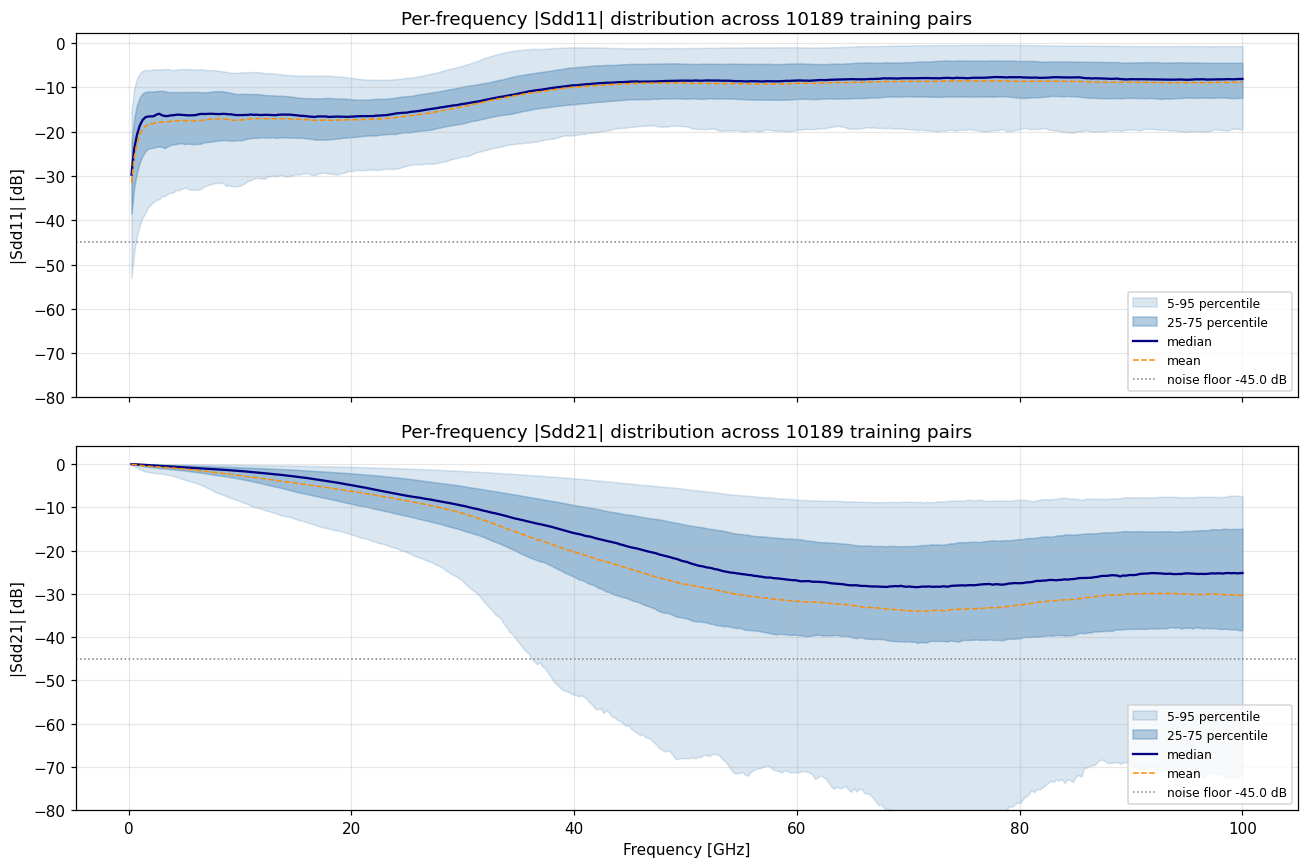

Saved 01_per_freq_magnitude_distribution.png


In [4]:
#magnitude statistics

def magnitude_db(S_complex, i, j):
    return 20.0 * np.log10(np.abs(S_complex[..., i, j]) + EPS)

def per_freq_stats(arr_db):
    return {
        "mean":   arr_db.mean(axis=0),
        "median": np.median(arr_db, axis=0),
        "std":    arr_db.std(axis=0),
        "p05":    np.percentile(arr_db, 5,  axis=0),
        "p25":    np.percentile(arr_db, 25, axis=0),
        "p75":    np.percentile(arr_db, 75, axis=0),
        "p95":    np.percentile(arr_db, 95, axis=0),
    }

# Compute for the primary differential elements
Sdd11_db_train = magnitude_db(Y_complex_train, 0, 0)
Sdd21_db_train = magnitude_db(Y_complex_train, 1, 0)
Sdd11_db_val   = magnitude_db(Y_complex_val,   0, 0)
Sdd21_db_val   = magnitude_db(Y_complex_val,   1, 0)

stats_Sdd11 = per_freq_stats(Sdd11_db_train)
stats_Sdd21 = per_freq_stats(Sdd21_db_train)
stats_Sdd11_val = per_freq_stats(Sdd11_db_val)
stats_Sdd21_val = per_freq_stats(Sdd21_db_val)

# Plot envelope for both elements
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, label, stats in zip(axes, ["|Sdd11|", "|Sdd21|"], [stats_Sdd11, stats_Sdd21]):
    ax.fill_between(freqs_ghz, stats["p05"], stats["p95"],
                     alpha=0.20, color="steelblue", label="5-95 percentile")
    ax.fill_between(freqs_ghz, stats["p25"], stats["p75"],
                     alpha=0.40, color="steelblue", label="25-75 percentile")
    ax.plot(freqs_ghz, stats["median"], color="navy", lw=1.5, label="median")
    ax.plot(freqs_ghz, stats["mean"],   color="darkorange", lw=1.0, ls="--", label="mean")
    ax.axhline(NOISE_FLOOR_DB, color="gray", ls=":", lw=1.0,
                label=f"noise floor {NOISE_FLOOR_DB} dB")
    ax.set_ylabel(f"{label} [dB]")
    ax.set_title(f"Per-frequency {label} distribution across {len(train_idx)} training pairs")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(bottom=-80)
axes[-1].set_xlabel("Frequency [GHz]")
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "01_per_freq_magnitude_distribution.png", bbox_inches="tight")
plt.show()
print("Saved 01_per_freq_magnitude_distribution.png")

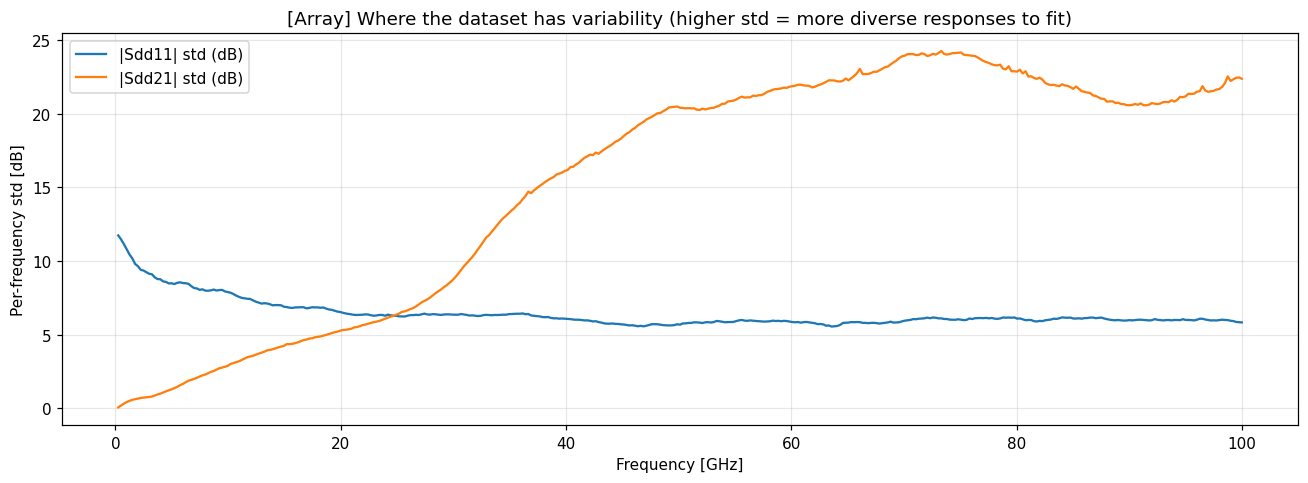


Sdd11 / Sdd21 std curves cross at approximately 24.7 GHz
At DC: Sdd11 std = 11.74 dB, Sdd21 std = 0.06 dB
At Nyquist (28 GHz): Sdd11 std = 6.36 dB, Sdd21 std = 7.52 dB
At 80 GHz: Sdd11 std = 6.08 dB, Sdd21 std = 22.86 dB


In [5]:
#standard deviation 

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.plot(freqs_ghz, stats_Sdd11["std"], color="C0", lw=1.5, label="|Sdd11| std (dB)")
ax.plot(freqs_ghz, stats_Sdd21["std"], color="C1", lw=1.5, label="|Sdd21| std (dB)")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Per-frequency std [dB]")
ax.set_title(f"[{DATASET_NAME}] Where the dataset has variability "
              "(higher std = more diverse responses to fit)")
ax.legend()
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "02_per_freq_std.png", bbox_inches="tight")
plt.show()

# Print key crossover frequencies
crossover_idx = np.argmin(np.abs(stats_Sdd11["std"] - stats_Sdd21["std"]))
print(f"\nSdd11 / Sdd21 std curves cross at approximately {freqs_ghz[crossover_idx]:.1f} GHz")
print(f"At DC: Sdd11 std = {stats_Sdd11['std'][0]:.2f} dB, Sdd21 std = {stats_Sdd21['std'][0]:.2f} dB")
print(f"At Nyquist (28 GHz): Sdd11 std = {stats_Sdd11['std'][np.argmin(np.abs(freqs_ghz-28))]:.2f} dB, "
      f"Sdd21 std = {stats_Sdd21['std'][np.argmin(np.abs(freqs_ghz-28))]:.2f} dB")
print(f"At 80 GHz: Sdd11 std = {stats_Sdd11['std'][np.argmin(np.abs(freqs_ghz-80))]:.2f} dB, "
      f"Sdd21 std = {stats_Sdd21['std'][np.argmin(np.abs(freqs_ghz-80))]:.2f} dB")

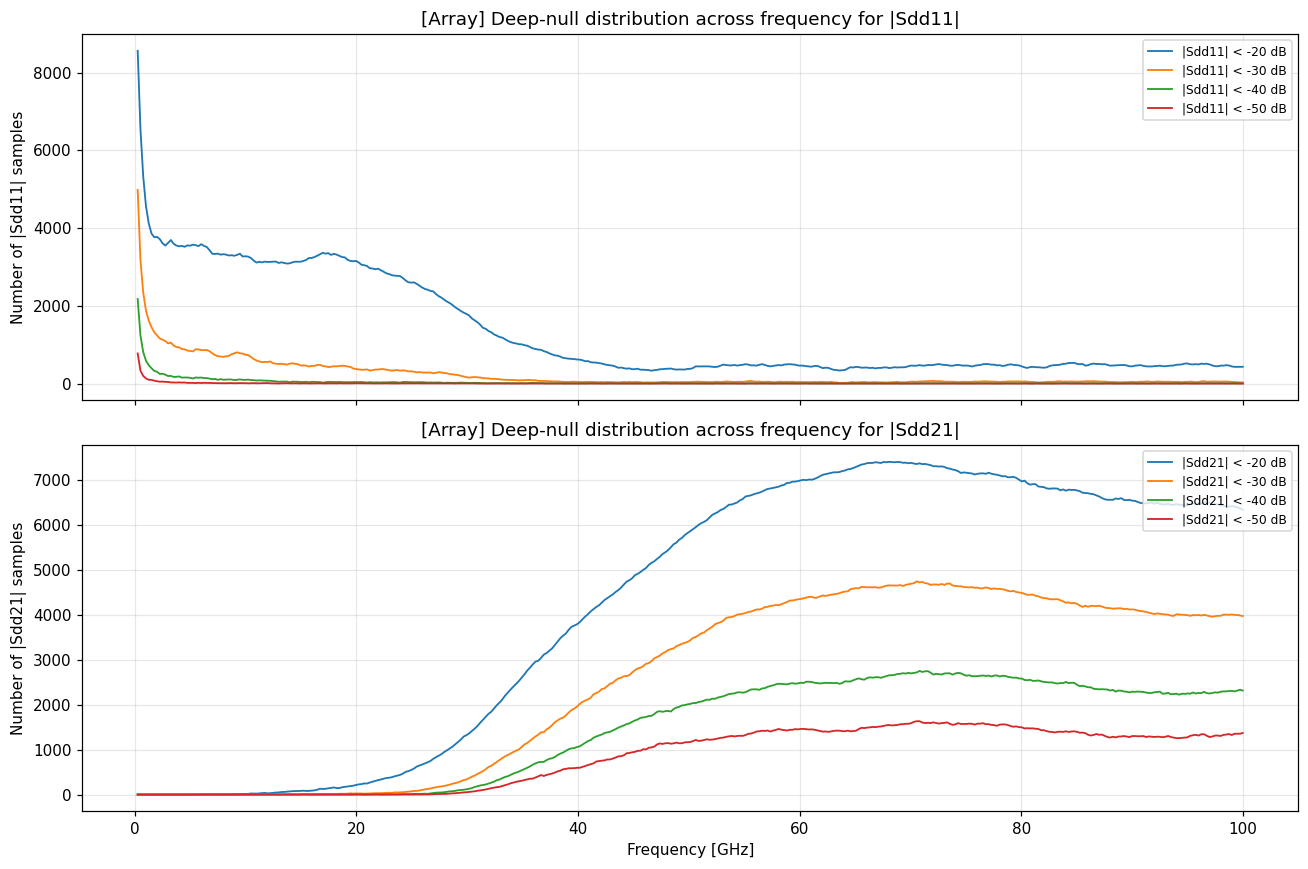


[Array] Fraction of training samples with at least one null < -30 dB per band:
  Band            |Sdd11|    |Sdd21|
    0- 14 GHz       77.2%       0.4%
   14- 28 GHz       40.8%       5.4%
   28- 42 GHz       12.1%      31.3%
   42- 56 GHz        7.1%      58.1%
   56-100 GHz       20.8%      82.5%


In [6]:
#deep null clustering analysis

def count_below(arr_db, threshold):
    return (arr_db < threshold).sum(axis=0)

thresholds = [-20, -30, -40, -50]
null_counts_Sdd11 = {t: count_below(Sdd11_db_train, t) for t in thresholds}
null_counts_Sdd21 = {t: count_below(Sdd21_db_train, t) for t in thresholds}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, label, counts in zip(axes, ["|Sdd11|", "|Sdd21|"],
                              [null_counts_Sdd11, null_counts_Sdd21]):
    for t in thresholds:
        ax.plot(freqs_ghz, counts[t], lw=1.2, label=f"{label} < {t} dB")
    ax.set_ylabel(f"Number of {label} samples")
    ax.set_title(f"[{DATASET_NAME}] Deep-null distribution across frequency for {label}")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Frequency [GHz]")
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "03_deep_null_distribution.png", bbox_inches="tight")
plt.show()

# Per-band tabulation: fraction of training samples with at least one null below -30 dB
band_ranges = [(0, 14), (14, 28), (28, 42), (42, 56), (56, 100)]
print(f"\n[{DATASET_NAME}] Fraction of training samples with at least one null < -30 dB per band:")
print(f"  {'Band':12s}  {'|Sdd11|':>9s}  {'|Sdd21|':>9s}")
for f_lo, f_hi in band_ranges:
    mask = (freqs_ghz >= f_lo) & (freqs_ghz < f_hi)
    f_min_S11 = (Sdd11_db_train[:, mask].min(axis=1) < -30).mean() * 100
    f_min_S21 = (Sdd21_db_train[:, mask].min(axis=1) < -30).mean() * 100
    print(f"  {f_lo:3d}-{f_hi:3d} GHz   {f_min_S11:>8.1f}%  {f_min_S21:>8.1f}%")

In [7]:
# === Forward model architecture (must match training) ===

class Conv1DResBlock(nn.Module):
    def __init__(self, channels, dropout=0.10):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 5, padding=2, padding_mode="replicate")
        self.norm1 = nn.GroupNorm(4, channels)
        self.conv2 = nn.Conv1d(channels, channels, 5, padding=2, padding_mode="replicate")
        self.norm2 = nn.GroupNorm(4, channels)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.norm1(x); h = F.silu(self.conv1(h)); h = self.drop(h)
        h = self.norm2(h); h = self.conv2(h)
        return x + h

class DirectSequenceResNet(nn.Module):
    UPPER_R = (0, 0, 0, 0, 1, 1, 1, 2, 2, 3)
    UPPER_C = (0, 1, 2, 3, 1, 2, 3, 2, 3, 3)

    def __init__(self, d_local=8, d_global=6, d_context=7,
                 F_len=401, hidden_dim=384, n_blocks=8):
        super().__init__()
        self.F_len = F_len
        self.is_link_dataset = (d_global == 7)
        in_dim = d_local + d_global + d_context
        self.geom_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.SiLU(),
        )
        self.learnable_velocity = nn.Parameter(torch.tensor(10.0))
        self.proj_in = nn.Conv1d(hidden_dim + 3, hidden_dim, kernel_size=1)
        self.blocks = nn.ModuleList(
            [Conv1DResBlock(hidden_dim, dropout=0.10) for _ in range(n_blocks)]
        )
        self.proj_out = nn.Conv1d(hidden_dim, 20, kernel_size=1)
        self.register_buffer("upper_r", torch.tensor(self.UPPER_R, dtype=torch.long))
        self.register_buffer("upper_c", torch.tensor(self.UPPER_C, dtype=torch.long))

    def _scatter_symmetric(self, vr, vi, B):
        m  = torch.zeros((B, 4, 4, self.F_len), dtype=torch.float64, device=vr.device)
        mi = torch.zeros((B, 4, 4, self.F_len), dtype=torch.float64, device=vr.device)
        m[:,  self.upper_r, self.upper_c, :] = vr.to(torch.float64)
        m[:,  self.upper_c, self.upper_r, :] = vr.to(torch.float64)
        mi[:, self.upper_r, self.upper_c, :] = vi.to(torch.float64)
        mi[:, self.upper_c, self.upper_r, :] = vi.to(torch.float64)
        return torch.complex(m, mi).permute(0, 3, 1, 2)

    def forward(self, xl, xg, xc, freqs_hz_t):
        B = xl.shape[0]
        x = torch.cat([xl, xg, xc], dim=-1)
        h_geom = self.geom_mlp(x)
        h_seq  = h_geom.unsqueeze(-1).expand(-1, -1, self.F_len)
        f_norm = (freqs_hz_t / freqs_hz_t.max()).view(1, 1, self.F_len)
        f_norm = f_norm.expand(B, 1, -1).to(h_seq.dtype)
        length = (xg[:, -1].view(B, 1, 1) if self.is_link_dataset
                  else torch.zeros((B, 1, 1), device=x.device, dtype=h_seq.dtype))
        phase = self.learnable_velocity * f_norm * length
        h = torch.cat([h_seq, f_norm, torch.sin(phase), torch.cos(phase)], dim=1)
        h = self.proj_in(h)
        for blk in self.blocks: h = blk(h)
        out = self.proj_out(h)
        return self._scatter_symmetric(out[:, :10, :], out[:, 10:, :], B)

In [8]:
# Try to load the forward model and compute per-frequency MAE on the val set
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model_available = False
mae_Sdd11_per_freq = None
mae_Sdd21_per_freq = None

try:
    model = DirectSequenceResNet(
        d_local=d_local, d_global=d_global, d_context=d_context,
        F_len=F_LEN, hidden_dim=384, n_blocks=8,
    ).to(device)
    state = torch.load(FORWARD_MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    model_available = True
    print(f"Forward model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
except FileNotFoundError:
    print(f"Forward checkpoint not found at {FORWARD_MODEL_PATH}")
    print("Section 5 will be skipped; the rest of the EDA runs without it.")
except Exception as e:
    print(f"Could not load forward model ({e}); skipping per-freq error analysis.")

if model_available:
    BATCH = 64
    freqs_hz_t = torch.from_numpy(freqs_hz).to(device).to(torch.float64)
    xl_v = payload["X_local"][val_idx]
    xg_v = payload["X_global"][val_idx]
    xc_v = payload["X_context"][val_idx]
    yr_v = payload["Y_real"][val_idx]
    yi_v = payload["Y_imag"][val_idx]

    err_S11_sum = np.zeros(F_LEN); mask_S11_sum = np.zeros(F_LEN)
    err_S21_sum = np.zeros(F_LEN); mask_S21_sum = np.zeros(F_LEN)

    with torch.no_grad():
        for i in range(0, len(val_idx), BATCH):
            sl = slice(i, i + BATCH)
            S_pred = model(xl_v[sl].to(device), xg_v[sl].to(device),
                            xc_v[sl].to(device), freqs_hz_t).cpu()
            S_tgt  = torch.complex(yr_v[sl].to(torch.float64),
                                    yi_v[sl].to(torch.float64))
            p_db = 20.0 * torch.log10(S_pred.abs().clamp_min(EPS))
            t_db = 20.0 * torch.log10(S_tgt.abs().clamp_min(EPS))
            mask11 = (t_db[..., 0, 0] > NOISE_FLOOR_DB).to(torch.float64).numpy()
            mask21 = (t_db[..., 1, 0] > NOISE_FLOOR_DB).to(torch.float64).numpy()
            err11 = (p_db[..., 0, 0] - t_db[..., 0, 0]).abs().numpy() * mask11
            err21 = (p_db[..., 1, 0] - t_db[..., 1, 0]).abs().numpy() * mask21
            err_S11_sum += err11.sum(axis=0); mask_S11_sum += mask11.sum(axis=0)
            err_S21_sum += err21.sum(axis=0); mask_S21_sum += mask21.sum(axis=0)

    mae_Sdd11_per_freq = err_S11_sum / (mask_S11_sum + 1e-6)
    mae_Sdd21_per_freq = err_S21_sum / (mask_S21_sum + 1e-6)
    valid_frac_Sdd11 = mask_S11_sum / len(val_idx)
    valid_frac_Sdd21 = mask_S21_sum / len(val_idx)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(freqs_ghz, mae_Sdd11_per_freq, color="C0", lw=1.5, label="|Sdd11| MAE")
    axes[0].plot(freqs_ghz, mae_Sdd21_per_freq, color="C1", lw=1.5, label="|Sdd21| MAE")
    axes[0].axhline(2.0, color="g", ls=":", lw=0.8, label="2 dB target")
    axes[0].set_ylabel("Per-freq MAE [dB]")
    axes[0].set_title(f"[{DATASET_NAME}] Forward model error vs frequency (val, passband-masked)")
    axes[0].legend()
    axes[1].plot(freqs_ghz, valid_frac_Sdd11 * 100, color="C0", lw=1.0, label="|Sdd11| above noise floor")
    axes[1].plot(freqs_ghz, valid_frac_Sdd21 * 100, color="C1", lw=1.0, label="|Sdd21| above noise floor")
    axes[1].set_ylabel("Valid sample fraction [%]"); axes[1].set_xlabel("Frequency [GHz]")
    axes[1].set_title("Passband validity per frequency")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(EDA_OUT_DIR / "04_forward_model_per_freq_mae.png", bbox_inches="tight")
    plt.show()

Device: cuda
Forward checkpoint not found at /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/sandbox_v1/models/forward_runs/run_2026-06-01_213554_direct_resnet_array/checkpoint_best.pt
Section 5 will be skipped; the rest of the EDA runs without it.


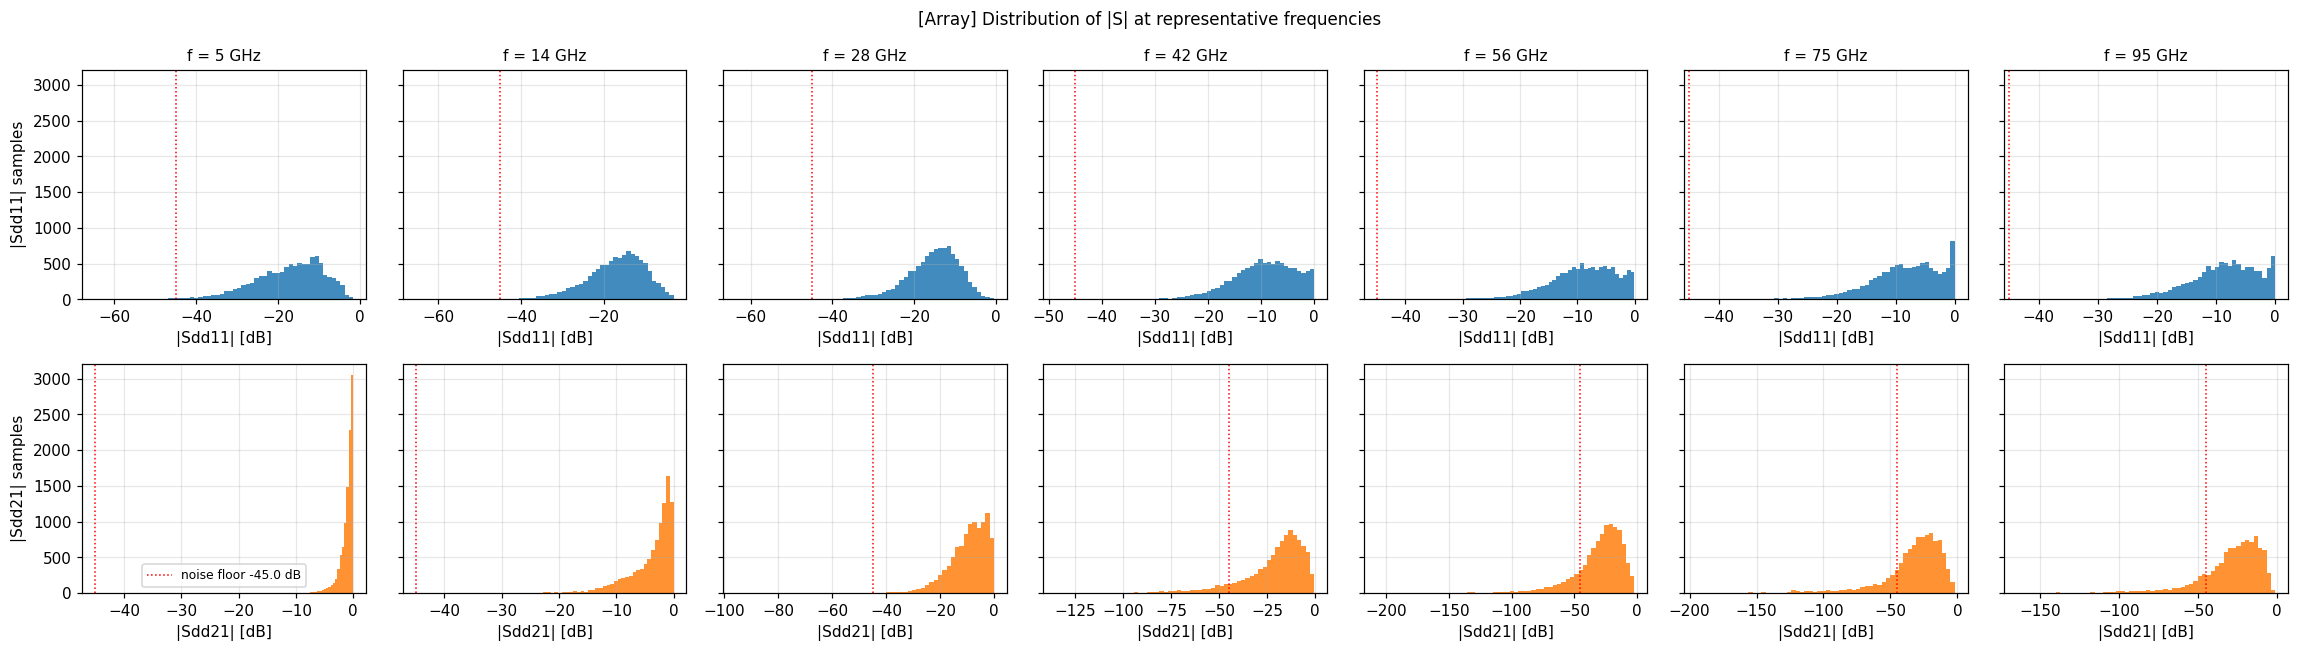

  |S| < -40 dB: |Sdd11| 0.38% (peak 21.34%)  |Sdd21| 14.14% (peak 26.97%)
  |S| < -45 dB: |Sdd11| 0.16% (peak 13.39%)  |Sdd21| 10.68% (peak 20.17%)
  |S| < -50 dB: |Sdd11| 0.07% (peak 7.60%)  |Sdd21| 8.16% (peak 16.00%)
  |S| < -55 dB: |Sdd11| 0.03% (peak 3.87%)  |Sdd21| 6.34% (peak 12.81%)


In [9]:
#noise floor verification

sample_freqs_ghz = [5, 14, 28, 42, 56, 75, 95]
sample_indices = [int(np.argmin(np.abs(freqs_ghz - f))) for f in sample_freqs_ghz]

fig, axes = plt.subplots(2, len(sample_freqs_ghz),
                          figsize=(3.0 * len(sample_freqs_ghz), 6),
                          sharey=True)
for col, (fghz, fidx) in enumerate(zip(sample_freqs_ghz, sample_indices)):
    ax = axes[0, col]
    ax.hist(Sdd11_db_train[:, fidx], bins=60, color="C0", alpha=0.85)
    ax.axvline(NOISE_FLOOR_DB, color="r", ls=":", lw=1.0)
    ax.set_title(f"f = {fghz} GHz", fontsize=10)
    if col == 0: ax.set_ylabel("|Sdd11| samples")
    ax.set_xlabel("|Sdd11| [dB]")
    ax = axes[1, col]
    ax.hist(Sdd21_db_train[:, fidx], bins=60, color="C1", alpha=0.85)
    ax.axvline(NOISE_FLOOR_DB, color="r", ls=":", lw=1.0,
                label=f"noise floor {NOISE_FLOOR_DB} dB" if col == 0 else None)
    if col == 0:
        ax.set_ylabel("|Sdd21| samples"); ax.legend(fontsize=8)
    ax.set_xlabel("|Sdd21| [dB]")

fig.suptitle(f"[{DATASET_NAME}] Distribution of |S| at representative frequencies",
              fontsize=11)
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "05_noise_floor_histograms.png", bbox_inches="tight")
plt.show()

for thresh in [-40, -45, -50, -55]:
    b11 = (Sdd11_db_train < thresh).mean(axis=0)
    b21 = (Sdd21_db_train < thresh).mean(axis=0)
    print(f"  |S| < {thresh} dB: "
          f"|Sdd11| {b11.mean()*100:.2f}% (peak {b11.max()*100:.2f}%)  "
          f"|Sdd21| {b21.mean()*100:.2f}% (peak {b21.max()*100:.2f}%)")

In [10]:
#complete element analysis

# Aggregate (i, j) indices by physical element type
ELEMENT_TYPE_INDICES = OrderedDict([
    ("Sdd_return",    [(0, 0), (1, 1)]),
    ("Sdd_insertion", [(0, 1), (1, 0)]),
    ("Sdc",           [(0, 2), (0, 3), (1, 2), (1, 3),
                       (2, 0), (2, 1), (3, 0), (3, 1)]),
    ("Scc_return",    [(2, 2), (3, 3)]),
    ("Scc_insertion", [(2, 3), (3, 2)]),
])

element_stats = OrderedDict()
print(f"[{DATASET_NAME}] Per-element-type statistics (all training samples):\n")
print(f"  {'Element type':16s}  {'n samples':>10s}  {'median dB range':>20s}  {'mean std dB':>11s}")
print("  " + "-" * 65)
for elem_type, indices in ELEMENT_TYPE_INDICES.items():
    mag_list = [np.sqrt(Y_complex_train[:, :, i, j].real**2
                         + Y_complex_train[:, :, i, j].imag**2)
                 for (i, j) in indices]
    all_mags = np.concatenate(mag_list, axis=0)
    all_mags_db = 20.0 * np.log10(all_mags + EPS)
    all_mags_sq = all_mags ** 2
    median_db = np.median(all_mags_db, axis=0)
    std_db    = all_mags_db.std(axis=0)
    p25, p75  = np.percentile(all_mags_db, [25, 75], axis=0)
    live_frac = (all_mags_sq > LIVE_SIGNAL_THRESHOLD).mean(axis=0)
    dead_frac = (all_mags_sq < DEAD_SIGNAL_THRESHOLD).mean(axis=0)
    null_frac_db = (all_mags_db < -30).mean(axis=0)
    element_stats[elem_type] = dict(
        median_db=median_db, std_db=std_db, p25=p25, p75=p75,
        live_frac=live_frac, dead_frac=dead_frac, null_frac_db=null_frac_db,
        n_samples=all_mags.shape[0],
    )
    print(f"  {elem_type:16s}  {all_mags.shape[0]:>10,}  "
          f"[{median_db.min():>6.1f}, {median_db.max():>6.1f}]  "
          f"{std_db.mean():>10.2f}")

[Array] Per-element-type statistics (all training samples):

  Element type       n samples       median dB range  mean std dB
  -----------------------------------------------------------------
  Sdd_return            20,378  [ -29.7,   -7.6]        6.41
  Sdd_insertion         20,378  [ -28.4,   -0.0]       15.42
  Sdc                   81,512  [ -52.1,  -26.4]       17.47
  Scc_return            20,378  [ -28.6,   -4.0]        5.33
  Scc_insertion         20,378  [ -34.6,   -0.0]       18.29


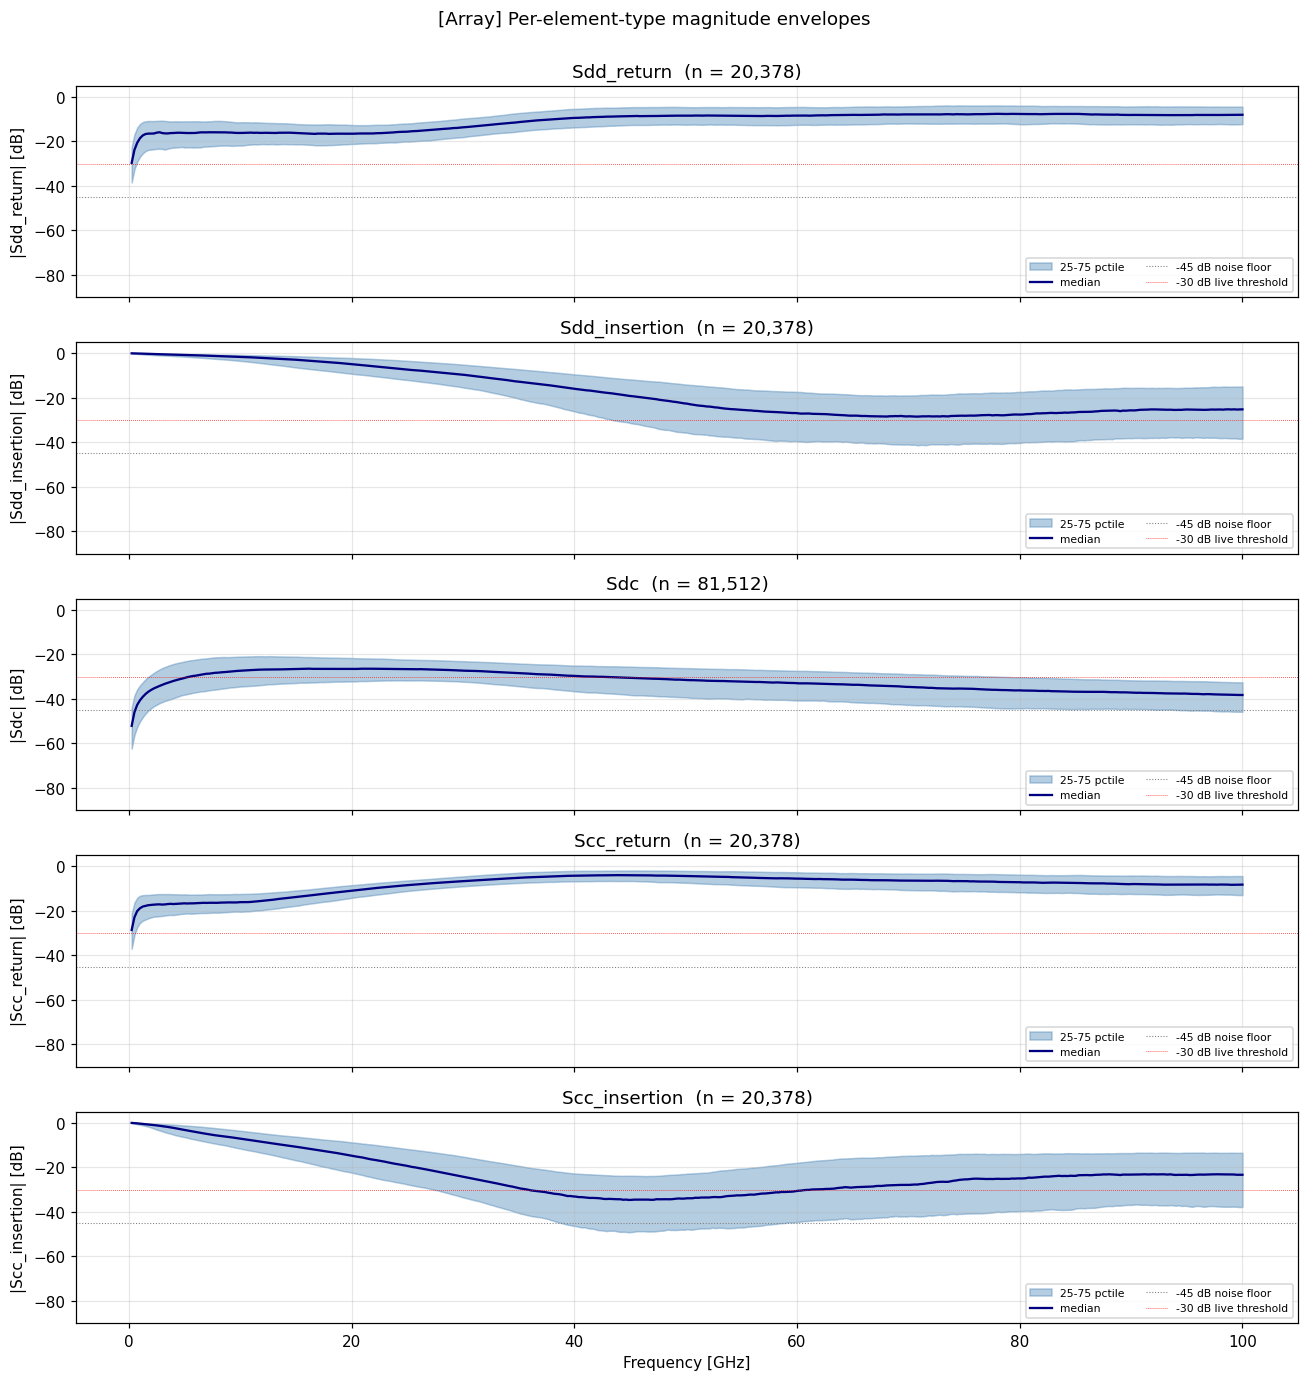

In [11]:
# Plot envelopes for all element types
fig, axes = plt.subplots(len(ELEMENT_TYPE_INDICES), 1,
                          figsize=(12, 2.5 * len(ELEMENT_TYPE_INDICES)),
                          sharex=True)
for ax, (et, st) in zip(axes, element_stats.items()):
    ax.fill_between(freqs_ghz, st["p25"], st["p75"],
                     alpha=0.40, color="steelblue", label="25-75 pctile")
    ax.plot(freqs_ghz, st["median_db"], color="navy", lw=1.5, label="median")
    ax.axhline(NOISE_FLOOR_DB, color="gray", ls=":", lw=0.7,
                label=f"-45 dB noise floor")
    ax.axhline(-30, color="red", ls=":", lw=0.5, label="-30 dB live threshold")
    ax.set_ylabel(f"|{et}| [dB]")
    ax.set_title(f"{et}  (n = {st['n_samples']:,})")
    ax.set_ylim(-90, 5)
    ax.legend(loc="lower right", fontsize=7, ncol=2)
axes[-1].set_xlabel("Frequency [GHz]")
fig.suptitle(f"[{DATASET_NAME}] Per-element-type magnitude envelopes",
              fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "06_all_element_types_envelope.png", bbox_inches="tight")
plt.show()

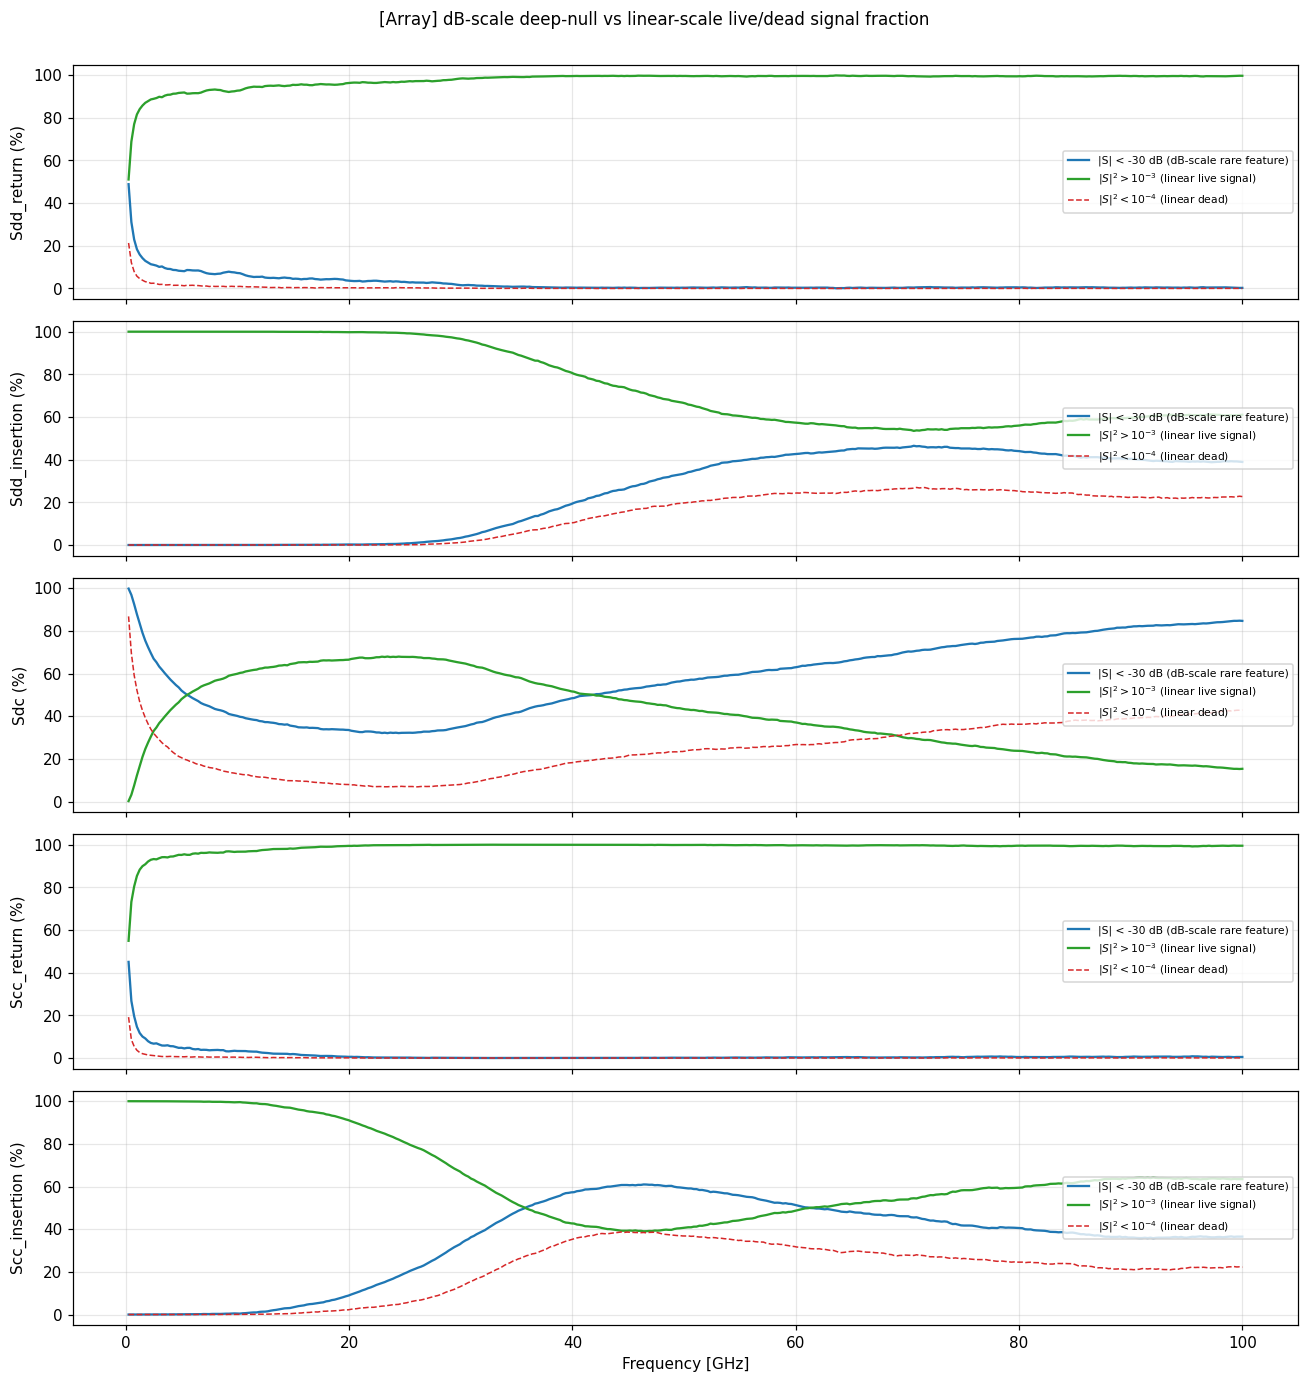

In [12]:
#linear scale signal analysis

fig, axes = plt.subplots(len(ELEMENT_TYPE_INDICES), 1,
                          figsize=(12, 2.5 * len(ELEMENT_TYPE_INDICES)),
                          sharex=True)
for ax, (et, st) in zip(axes, element_stats.items()):
    ax.plot(freqs_ghz, st["null_frac_db"] * 100, color="C0", lw=1.5,
             label="|S| < -30 dB (dB-scale rare feature)")
    ax.plot(freqs_ghz, st["live_frac"] * 100, color="C2", lw=1.5,
             label=r"$|S|^2 > 10^{-3}$ (linear live signal)")
    ax.plot(freqs_ghz, st["dead_frac"] * 100, color="C3", lw=1.0, ls="--",
             label=r"$|S|^2 < 10^{-4}$ (linear dead)")
    ax.set_ylabel(f"{et} (%)")
    ax.set_ylim(-5, 105)
    ax.legend(loc="center right", fontsize=7)
axes[-1].set_xlabel("Frequency [GHz]")
fig.suptitle(f"[{DATASET_NAME}] dB-scale deep-null vs linear-scale live/dead signal fraction",
              fontsize=11, y=1.002)
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "07_dB_vs_linear_rare_features.png", bbox_inches="tight")
plt.show()

In [13]:
BANDS = [
    ("0-14 GHz",     0,  14),
    ("14-28 GHz",   14,  28),
    ("28-42 GHz",   28,  42),
    ("42-56 GHz",   42,  56),
    ("56-100 GHz",  56, 100),
]

def band_mask(f_lo, f_hi):
    return (freqs_ghz >= f_lo) & (freqs_ghz < f_hi)

# Per-band statistics for all element types
print(f"\n[{DATASET_NAME}] Per-band statistics per element type:\n")
band_summaries = OrderedDict()
for et, st in element_stats.items():
    band_summaries[et] = OrderedDict()
    print(f"--- {et} ---")
    print(f"  {'Band':12s}  {'med dB':>8s}  {'std dB':>8s}  "
          f"{'live %':>7s}  {'dead %':>7s}  {'dB null %':>10s}")
    print("  " + "-" * 65)
    for bn, f_lo, f_hi in BANDS:
        m = band_mask(f_lo, f_hi)
        med  = float(st["median_db"][m].mean())
        std  = float(st["std_db"][m].mean())
        live = float(st["live_frac"][m].mean()) * 100
        dead = float(st["dead_frac"][m].mean()) * 100
        null = float(st["null_frac_db"][m].mean()) * 100
        band_summaries[et][bn] = dict(
            f_lo_GHz=f_lo, f_hi_GHz=f_hi,
            median_db=med, std_db=std,
            live_frac=live/100, dead_frac=dead/100, null_frac_db=null/100,
        )
        print(f"  {bn:12s}  {med:>8.2f}  {std:>8.2f}  "
              f"{live:>6.1f}%  {dead:>6.1f}%  {null:>9.1f}%")
    print()


[Array] Per-band statistics per element type:

--- Sdd_return ---
  Band            med dB    std dB   live %   dead %   dB null %
  -----------------------------------------------------------------
  0-14 GHz        -16.70      8.45    90.5%     2.1%        9.5%
  14-28 GHz       -16.09      6.54    96.3%     0.3%        3.7%
  28-42 GHz       -11.51      6.26    99.0%     0.1%        1.0%
  42-56 GHz        -8.60      5.76    99.6%     0.0%        0.4%
  56-100 GHz       -8.05      5.97    99.6%     0.0%        0.4%

--- Sdd_insertion ---
  Band            med dB    std dB   live %   dead %   dB null %
  -----------------------------------------------------------------
  0-14 GHz         -1.15      2.04   100.0%     0.0%        0.0%
  14-28 GHz        -5.47      5.55    99.5%     0.1%        0.5%
  28-42 GHz       -12.77     12.86    88.8%     5.8%       11.2%
  42-56 GHz       -21.76     19.63    67.8%    18.7%       32.2%
  56-100 GHz      -26.86     22.24    57.4%    24.3%       

In [14]:
# ============================================================================
# Cell 10 — Per-element weight derivation (self-contained, dataset-agnostic)
# ============================================================================
# This cell takes the per-band statistics from Cell 9 and produces:
#   - derive_band_weight(): the rule mapping (median_db, std_db, band, mult) -> weight
#   - derived_weights:      auto-derived weights for every element-type aggregate
#                           (Sdd_return, Sdd_insertion, Sdc, Scc_return, Scc_insertion)
#   - ELEMENT_BANDS_FINAL:  the final (band, weight, rationale) scheme used to
#                           build the (4, 4, 401) tensor in Cell 11
#
# Sdd11 / Sdd21 / Sdc / Scc are ALL derived from data via the same rule. The
# only manual element-type knobs are:
#   - PRIMARY_PATH_AMPLIFIER (x1.3): boost Sdd11/Sdd21 over secondary paths
#   - element_multiplier (0.6 for Scc inside derive_band_weight): de-emphasise
#                                                                 common mode

# ---------------------------------------------------------------------------
# Step 1 — The weight-derivation rule
# ---------------------------------------------------------------------------
# Maps per-band statistics to a numerical weight. Three signals are combined:
#   (a) signal level (median dB)
#   (b) variability  (std dB) — proxy for whether there is geometric information
#   (c) 112G PAM4 industry priority — Nyquist boost, out-of-band cut
#
# Decision tree on median dB:
#   median > -25 dB and std > 5 dB   ->  w = 2.0   (strong, varied signal)
#   median in [-40, -25] dB          ->  w = 1.5   (moderate signal)
#   median in [-55, -40] dB, std > 5 ->  w = 1.0   (quiet but varied)
#   median < -55 dB and std < 5 dB   ->  w = 0.5   (solver-noise dominated)
#   otherwise                        ->  w = 1.0   (cautious default)
#
# Industry adjustment (applied after the base weight):
#   14-28 GHz Nyquist:      +0.5
#   56-100 GHz out-of-band: -0.5
#
# Element-type multiplier (applied last, before the clamp):
#   Sdd*, Sdc:  1.0
#   Scc*:       0.6   (common mode is least critical for differential SerDes)
#
# Result is clamped to [0.3, 3.0] before being returned.
def derive_band_weight(median_db, std_db, band_name, element_multiplier=1.0):
    """Map per-band statistics + industry priors to a numerical weight in [0.3, 3.0]."""
    # (a) signal level + variability => base weight
    if median_db > -25 and std_db > 5:
        w = 2.0
    elif median_db > -40:
        w = 1.5
    elif median_db > -55 and std_db > 5:
        w = 1.0
    elif median_db < -55 and std_db < 5:
        w = 0.5
    else:
        w = 1.0
    # (c) industry adjustment
    if band_name == "14-28 GHz":
        w += 0.5     # 112G PAM4 Nyquist priority
    elif band_name == "56-100 GHz":
        w -= 0.5     # out of 112G PAM4 spec
    # Element-type multiplier
    w *= element_multiplier
    return float(max(0.3, min(3.0, w)))


# ---------------------------------------------------------------------------
# Step 2 — Element-type multipliers
# ---------------------------------------------------------------------------
# These say "how important is this element type relative to the primary
# differential path". Sdd and Sdc get 1.0; Scc gets 0.6 because common-mode
# response is secondary for SerDes inverse design.
ELEMENT_MULTIPLIERS = {
    "Sdd_return":    1.0,
    "Sdd_insertion": 1.0,
    "Sdc":           1.0,
    "Scc_return":    0.6,
    "Scc_insertion": 0.6,
}


# ---------------------------------------------------------------------------
# Step 3 — Auto-derive weights for every element-type aggregate
# ---------------------------------------------------------------------------
# derived_weights[element_type][band_name] = {weight, median_db, std_db, ...}
# This is the lookup table used later by the Scc branch (which averages the
# return and insertion components). It is also a useful audit artifact.
print(f"\n[{DATASET_NAME}] Auto-derived weights from band statistics:\n")
print(f"  {'Element':18s}  {'Band':12s}  {'w':>5s}   rationale")
print("  " + "-" * 80)

derived_weights = OrderedDict()
for et, summaries in band_summaries.items():
    derived_weights[et] = OrderedDict()
    mult = ELEMENT_MULTIPLIERS[et]
    for band_name, bs in summaries.items():
        w = derive_band_weight(bs["median_db"], bs["std_db"], band_name,
                                element_multiplier=mult)
        derived_weights[et][band_name] = dict(
            weight=w,
            median_db=bs["median_db"],
            std_db=bs["std_db"],
            live_frac=bs["live_frac"],
        )
        print(f"  {et:18s}  {band_name:12s}  {w:>5.2f}   "
              f"med {bs['median_db']:>6.1f} dB  std {bs['std_db']:>5.2f} dB")


# ---------------------------------------------------------------------------
# Step 4 — Primary-path amplifier
# ---------------------------------------------------------------------------
# Sdd11 and Sdd21 are the elements the 112G PAM4 receiver actually measures.
# They get a modest x1.3 boost so the cVAE physics loss attends to them more
# strongly than the secondary mode-conversion path. The clamp inside
# build_data_driven_bands is raised to 5.0 so this amplifier can push the
# Nyquist band above 3.0 when the data supports it.
PRIMARY_PATH_AMPLIFIER = 1.3


def build_data_driven_bands(elem_type_key, all_summaries, amplifier=1.0):
    """
    Walk through the five PAM4 bands and apply derive_band_weight at each.

    Parameters
    ----------
    elem_type_key : str
        Top-level key of all_summaries: "Sdd_return", "Sdd_insertion",
        "Sdc", "Scc_return", or "Scc_insertion".
    all_summaries : dict
        The full band_summaries from Cell 9.
    amplifier : float
        Multiplicative boost. 1.3 for Sdd primary path; 1.0 otherwise.

    Returns
    -------
    List of (f_lo_GHz, f_hi_GHz, weight, rationale) tuples for Cell 11.
    """
    # Pull the band stats for this specific element type
    summaries = all_summaries[elem_type_key]

    spec = []
    for f_lo, f_hi in [(0, 14), (14, 28), (28, 42), (42, 56), (56, 100)]:
        band_name = f"{f_lo}-{f_hi} GHz"
        bs = summaries[band_name]
        # Apply the rule with element_multiplier=1.0 here (the Sdd_return /
        # Sdd_insertion / Sdc multipliers are already 1.0). For Scc we go
        # through derived_weights below, which already had multiplier=0.6
        # baked in.
        w = derive_band_weight(
            bs["median_db"], bs["std_db"], band_name,
            element_multiplier=1.0,
        ) * amplifier
        # Final clamp. Raised cap (5.0) gives the amplifier room to push
        # Nyquist band above 3.0 when data justifies it.
        w = float(max(0.3, min(5.0, w)))
        rationale = (
            f"data-driven: median {bs['median_db']:>6.1f} dB, "
            f"std {bs['std_db']:>5.2f} dB, "
            f"live {bs['live_frac']*100:>5.1f}% "
            f"(x{amplifier:.1f} amplifier)"
        )
        spec.append((f_lo, f_hi, w, rationale))
    return spec


# ---------------------------------------------------------------------------
# Step 5 — Assemble the final per-element band scheme
# ---------------------------------------------------------------------------
# All four element types get their weights from the same data-driven rule.
# No hand-tuned tables; no dataset-specific overrides. Sdd11 / Sdd21 get the
# x1.3 primary-path amplifier; Sdc gets the multiplier 1.0 baseline; Scc is
# averaged across return / insertion components (both already at multiplier
# 0.6 via derived_weights).
ELEMENT_BANDS_FINAL = OrderedDict([
    # Primary differential path — amplified
    ("Sdd11", build_data_driven_bands("Sdd_return",    band_summaries, PRIMARY_PATH_AMPLIFIER)),
    ("Sdd21", build_data_driven_bands("Sdd_insertion", band_summaries, PRIMARY_PATH_AMPLIFIER)),
    # Mode conversion — baseline
    ("Sdc",   build_data_driven_bands("Sdc",           band_summaries, amplifier=1.0)),
    # Common mode — average of return / insertion (both already include x0.6)
    ("Scc", [
        (f_lo, f_hi,
         0.5 * (derived_weights["Scc_return"][band_name]["weight"]
                + derived_weights["Scc_insertion"][band_name]["weight"]),
         f"data-driven: mean of Scc_return "
         f"({derived_weights['Scc_return'][band_name]['weight']:.2f}) and "
         f"Scc_insertion ({derived_weights['Scc_insertion'][band_name]['weight']:.2f})")
        for band_name, f_lo, f_hi in BANDS
    ]),
])


# ---------------------------------------------------------------------------
# Step 6 — Print the final scheme for sanity-checking
# ---------------------------------------------------------------------------
print(f"\n[{DATASET_NAME}] Final per-element band scheme:")
for et, spec in ELEMENT_BANDS_FINAL.items():
    print(f"\n  {et}:")
    for f_lo, f_hi, w, rat in spec:
        print(f"    {f_lo:3d}-{f_hi:3d} GHz  w={w:>5.2f}   {rat[:70]}")


[Array] Auto-derived weights from band statistics:

  Element             Band              w   rationale
  --------------------------------------------------------------------------------
  Sdd_return          0-14 GHz       2.00   med  -16.7 dB  std  8.45 dB
  Sdd_return          14-28 GHz      2.50   med  -16.1 dB  std  6.54 dB
  Sdd_return          28-42 GHz      2.00   med  -11.5 dB  std  6.26 dB
  Sdd_return          42-56 GHz      2.00   med   -8.6 dB  std  5.76 dB
  Sdd_return          56-100 GHz     1.50   med   -8.1 dB  std  5.97 dB
  Sdd_insertion       0-14 GHz       1.50   med   -1.1 dB  std  2.04 dB
  Sdd_insertion       14-28 GHz      2.50   med   -5.5 dB  std  5.55 dB
  Sdd_insertion       28-42 GHz      2.00   med  -12.8 dB  std 12.86 dB
  Sdd_insertion       42-56 GHz      2.00   med  -21.8 dB  std 19.63 dB
  Sdd_insertion       56-100 GHz     1.00   med  -26.9 dB  std 22.24 dB
  Sdc                 0-14 GHz       1.50   med  -30.8 dB  std 16.11 dB
  Sdc             

In [15]:
#weight tensor 
def build_w_vector(band_spec):
    w = np.zeros(F_LEN, dtype=np.float64)
    for entry in band_spec:
        f_lo, f_hi, weight = entry[0], entry[1], entry[2]
        m = (freqs_ghz >= f_lo) & (freqs_ghz < f_hi)
        w[m] = weight
    w[freqs_ghz >= band_spec[-1][1]] = band_spec[-1][2]
    return w

w_vectors = {et: build_w_vector(spec)
             for et, spec in ELEMENT_BANDS_FINAL.items()}

# Mapping (i, j) -> element-type label
ELEMENT_TYPE_FOR_IJ = {
    (0, 0): "Sdd11", (1, 1): "Sdd11",
    (0, 1): "Sdd21", (1, 0): "Sdd21",
    (0, 2): "Sdc", (0, 3): "Sdc", (1, 2): "Sdc", (1, 3): "Sdc",
    (2, 0): "Sdc", (2, 1): "Sdc", (3, 0): "Sdc", (3, 1): "Sdc",
    (2, 2): "Scc", (2, 3): "Scc", (3, 2): "Scc", (3, 3): "Scc",
}

w_tensor = np.zeros((4, 4, F_LEN), dtype=np.float64)
for (i, j), et in ELEMENT_TYPE_FOR_IJ.items():
    w_tensor[i, j, :] = w_vectors[et]

assert np.allclose(w_tensor, w_tensor.transpose(1, 0, 2)), \
    "weight tensor failed symmetry check"
print(f"Tensor shape: {w_tensor.shape}")
print(f"Tensor range: [{w_tensor.min():.2f}, {w_tensor.max():.2f}]")
print(f"Symmetry verified (S = S^T): OK")

mean_w = w_tensor.mean(axis=-1)
print(f"\nMean weight per element (4x4, averaged over frequency):")
print(np.array2string(mean_w, precision=2, suppress_small=True))

Tensor shape: (4, 4, 401)
Tensor range: [0.75, 3.25]
Symmetry verified (S = S^T): OK

Mean weight per element (4x4, averaged over frequency):
[[2.4  2.03 1.35 1.35]
 [2.03 2.4  1.35 1.35]
 [1.35 1.35 0.92 0.92]
 [1.35 1.35 0.92 0.92]]


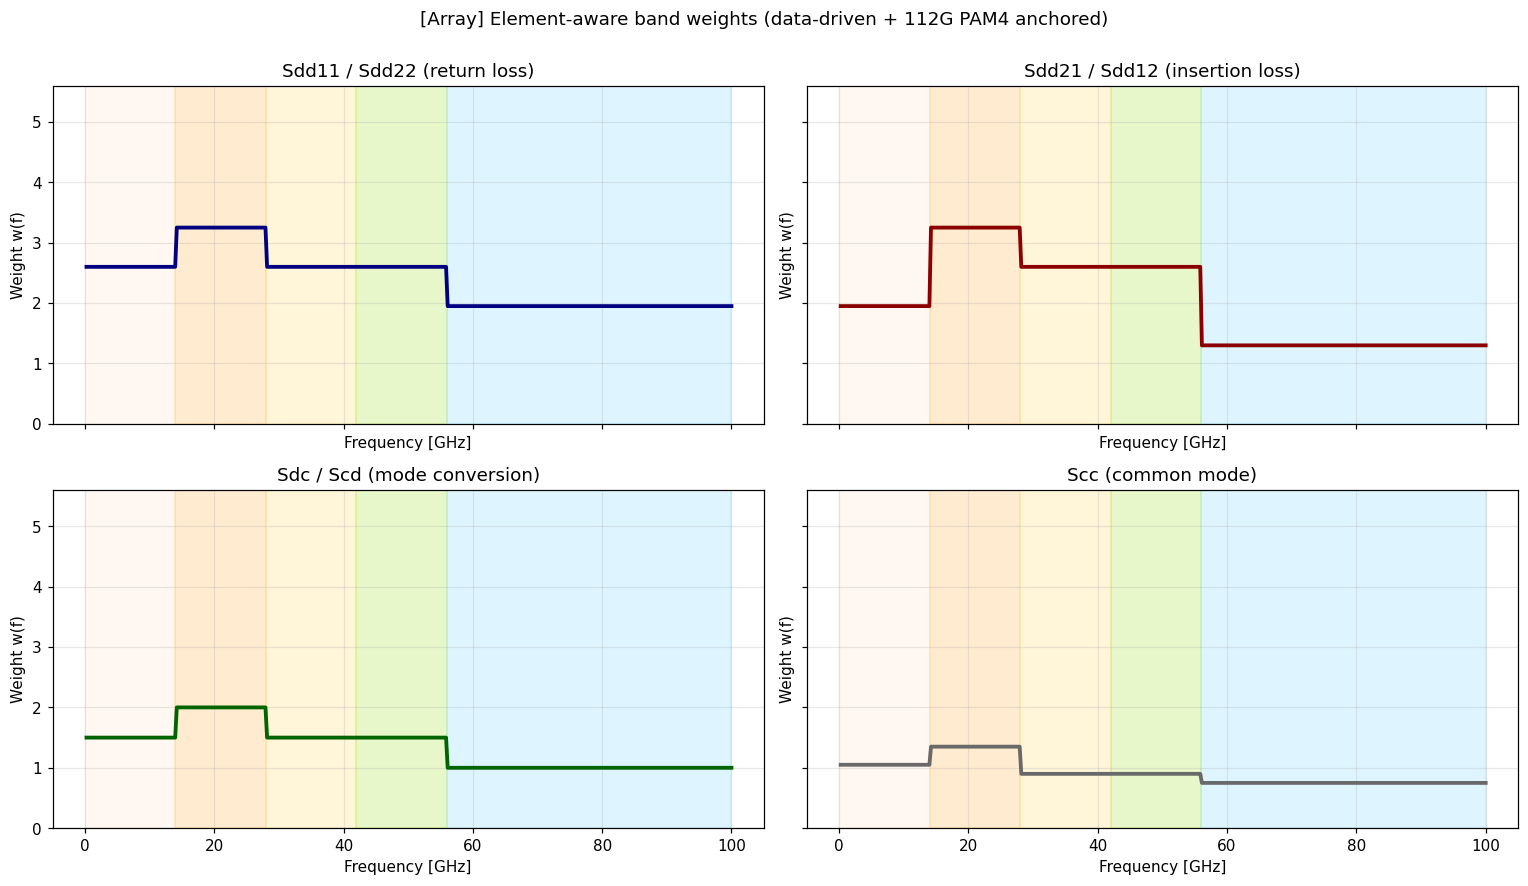

In [16]:
# Visualise the four per-element weight vectors with band shading
PAM4_EDGES = [0, 14, 28, 42, 56, 100]
PAM4_COLORS = ["#FFE6CC", "#FFB347", "#FFD96A", "#A6E22E", "#7FDBFF"]
PAM4_LABELS = ["0-14 (baseband)", "14-28 (Nyquist)", "28-42 (channel BW)",
                "42-56 (harmonics)", "56-100 (out of band)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
panels = [
    ("Sdd11 / Sdd22 (return loss)",    w_vectors["Sdd11"], "navy"),
    ("Sdd21 / Sdd12 (insertion loss)", w_vectors["Sdd21"], "darkred"),
    ("Sdc / Scd (mode conversion)",    w_vectors["Sdc"],   "darkgreen"),
    ("Scc (common mode)",              w_vectors["Scc"],   "dimgray"),
]
for ax, (title, w, color) in zip(axes.flat, panels):
    for k in range(5):
        ax.axvspan(PAM4_EDGES[k], PAM4_EDGES[k+1],
                   alpha=0.25, color=PAM4_COLORS[k],
                   label=PAM4_LABELS[k] if title == panels[0][0] else None)
    ax.plot(freqs_ghz, w, color=color, lw=2.5)
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Weight w(f)")
    ax.set_title(title)
    ax.set_ylim(0, 5.6)
fig.suptitle(f"[{DATASET_NAME}] Element-aware band weights "
              f"(data-driven + 112G PAM4 anchored)", fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / "08_element_aware_weights.png", bbox_inches="tight")
plt.show()

In [17]:
#save artifacts
# Build the JSON output
output_payload = {
    "dataset": DATASET_NAME,
    "version": "unified_eda_v1",
    "target_standard": "112G PAM4 (IEEE 802.3ck / OIF-CEI-112G-PAM4)",
    "noise_floor_db": NOISE_FLOOR_DB,
    "n_freq_points": int(F_LEN),
    "freq_ghz_min": float(freqs_ghz.min()),
    "freq_ghz_max": float(freqs_ghz.max()),
    "thresholds": {
        "live_signal_linear": LIVE_SIGNAL_THRESHOLD,
        "dead_signal_linear": DEAD_SIGNAL_THRESHOLD,
    },
    "element_type_map": {
        "Sdd11": "(i,j) in {(0,0), (1,1)} -> Sdd11, Sdd22 (return loss)",
        "Sdd21": "(i,j) in {(0,1), (1,0)} -> Sdd21, Sdd12 (insertion loss)",
        "Sdc":   "(i,j) in Sdc and Scd quadrants (mode conversion)",
        "Scc":   "(i,j) in Scc quadrant (common mode)",
    },
    "bands_per_element_type": {
        et: [
            {"f_lo_GHz": f_lo, "f_hi_GHz": f_hi,
             "weight": w, "rationale": rat}
            for (f_lo, f_hi, w, rat) in spec
        ]
        for et, spec in ELEMENT_BANDS_FINAL.items()
    },
    "per_band_statistics": {
        et: {bn: bs for bn, bs in summaries.items()}
        for et, summaries in band_summaries.items()
    },
    "tensor_shape": list(w_tensor.shape),
}

json_path = EDA_OUT_DIR / "weights_element_aware.json"
with open(json_path, "w") as f:
    json.dump(output_payload, f, indent=2)
print(f"Saved {json_path}")

npy_path = EDA_OUT_DIR / "weights_element_aware_per_freq.npy"
np.save(npy_path, w_tensor)
print(f"Saved {npy_path}")

for name, vec in w_vectors.items():
    p = EDA_OUT_DIR / f"weights_{name}_per_freq.npy"
    np.save(p, vec)
    print(f"Saved {p}")

Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_element_aware.json
Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_element_aware_per_freq.npy
Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_Sdd11_per_freq.npy
Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_Sdd21_per_freq.npy
Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_Sdc_per_freq.npy
Saved /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/results/data/frequency_eda/array/weights_Scc_p